
=== 1. DISTRIBUTIONS ===

=== 2. PARAMETER ESTIMATION (LINEAR) ===
LS/MLE: [2.20679059 0.4950814 ]
MAP: [2.05332326 0.51756157]

=== 3. NONLINEAR ESTIMATION ===
Nonlinear params: [2.69204455 0.10217337]

=== 4. CONFIDENCE INTERVALS ===
Mean CI: (np.float64(4.227632345657034), np.float64(5.550096240462547))
Proportion CI: (np.float64(0.5248660051214322), np.float64(0.7151339948785678))
Bootstrap CI: [4.54078845 5.44720304]

=== 5. CI COVERAGE ===
Coverage: 0.97

=== 6. HYPOTHESIS TESTING ===
t-stat: 2.3004248050869323
p-value: 0.028810026795013197

=== 7. FALSE POSITIVE RATE ===
False positive rate: 0.042

=== 8. A/B TEST ===
A: 0.088 B: 0.145
z: 3.9727717888148373 p: 7.104110472533343e-05

=== 9. SAMPLE SIZE EFFECT ===
n=100, p-value=0.36601
n=1000, p-value=0.82189
n=10000, p-value=0.00009


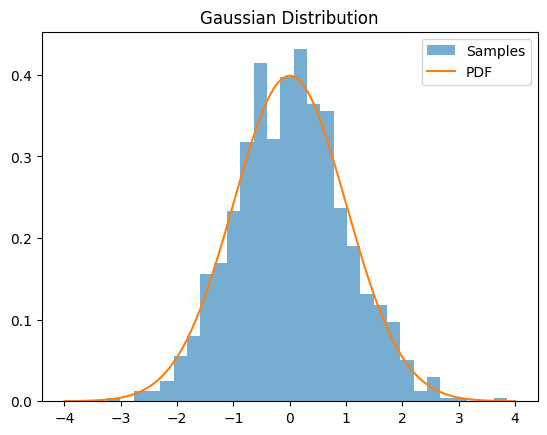

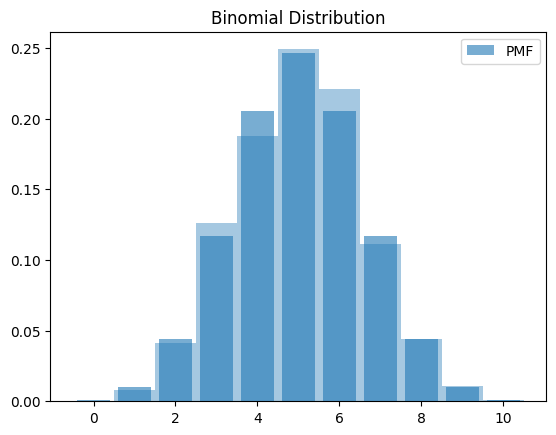

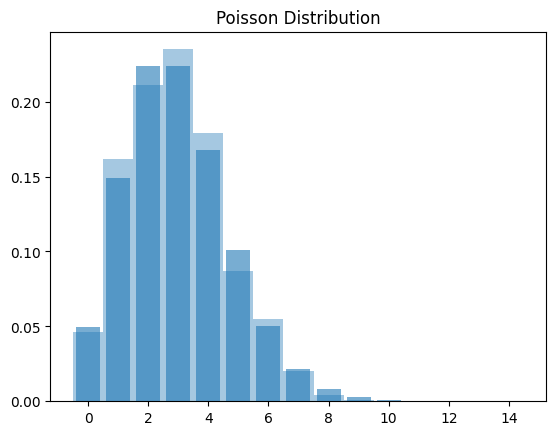

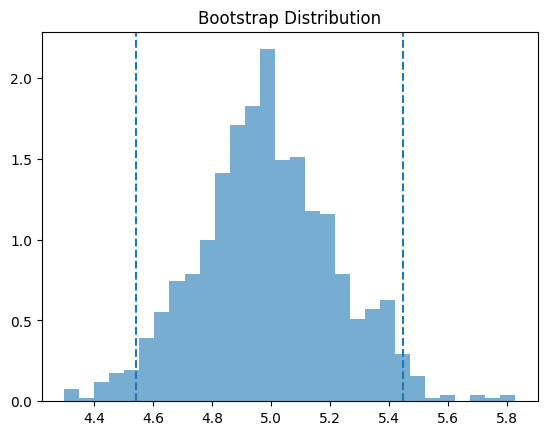

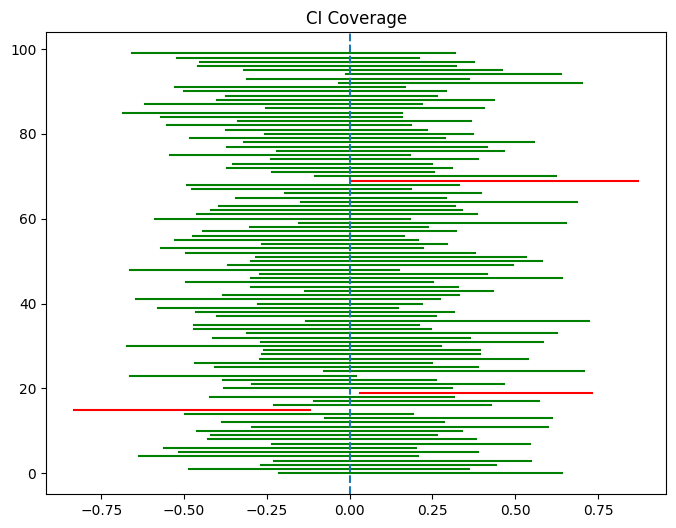

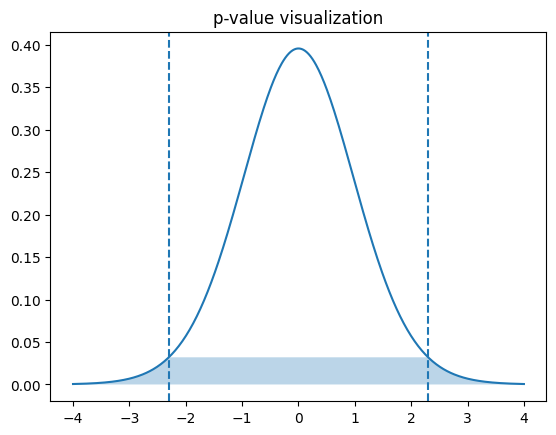

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

np.random.seed(42)

# =========================================================
# 1. PROBABILITY DISTRIBUTIONS
# =========================================================
print("\n=== 1. DISTRIBUTIONS ===")

# Gaussian
mu, sigma = 0, 1
samples = np.random.normal(mu, sigma, 1000)
x = np.linspace(-4, 4, 200)

plt.figure()
plt.hist(samples, bins=30, density=True, alpha=0.6, label="Samples")
plt.plot(x, stats.norm.pdf(x, mu, sigma), label="PDF")
plt.title("Gaussian Distribution")
plt.legend()

# Binomial
n, p = 10, 0.5
samples = np.random.binomial(n, p, 1000)
k = np.arange(0, n+1)

plt.figure()
plt.bar(k, stats.binom.pmf(k, n, p), alpha=0.6, label="PMF")
plt.hist(samples, bins=np.arange(-0.5, n+1.5, 1), density=True, alpha=0.4)
plt.title("Binomial Distribution")
plt.legend()

# Poisson
lam = 3
samples = np.random.poisson(lam, 1000)
k = np.arange(0, 15)

plt.figure()
plt.bar(k, stats.poisson.pmf(k, lam), alpha=0.6)
plt.hist(samples, bins=np.arange(-0.5, 15.5, 1), density=True, alpha=0.4)
plt.title("Poisson Distribution")

# =========================================================
# 2. PARAMETER ESTIMATION (LINEAR)
# =========================================================
print("\n=== 2. PARAMETER ESTIMATION (LINEAR) ===")

n = 50
x = np.linspace(0, 10, n)
true_beta0, true_beta1 = 2, 0.5
sigma = 1

y = true_beta0 + true_beta1 * x + np.random.normal(0, sigma, n)
X = np.column_stack((np.ones(n), x))

# Least Squares / MLE
beta_ls = np.linalg.inv(X.T @ X) @ X.T @ y

# MAP (ridge)
tau = 1.0
lambda_reg = sigma**2 / tau**2
beta_map = np.linalg.inv(X.T @ X + lambda_reg * np.eye(2)) @ X.T @ y

print("LS/MLE:", beta_ls)
print("MAP:", beta_map)

# =========================================================
# 3. NONLINEAR ESTIMATION (OPTIMIZATION)
# =========================================================
print("\n=== 3. NONLINEAR ESTIMATION ===")

def model(params, x):
    a, b = params
    return a * np.exp(b * x)

def loss(params):
    return np.sum((y - model(params, x))**2)

res = minimize(loss, [1, 0.1])
print("Nonlinear params:", res.x)

# =========================================================
# 4. CONFIDENCE INTERVALS
# =========================================================
print("\n=== 4. CONFIDENCE INTERVALS ===")

data = np.random.normal(5, 2, 50)
mean = np.mean(data)
std = np.std(data, ddof=1)

ci = stats.t.interval(0.95, df=49, loc=mean, scale=std/np.sqrt(50))
print("Mean CI:", ci)

# Proportion CI
data = np.random.binomial(1, 0.6, 100)
p_hat = np.mean(data)
z = stats.norm.ppf(0.975)
ci_prop = (p_hat - z*np.sqrt(p_hat*(1-p_hat)/100),
           p_hat + z*np.sqrt(p_hat*(1-p_hat)/100))
print("Proportion CI:", ci_prop)

# Bootstrap CI
def bootstrap(data, n_boot=1000):
    estimates = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        estimates.append(np.mean(sample))
    return np.percentile(estimates, [2.5, 97.5]), estimates

ci_boot, estimates = bootstrap(np.random.normal(5,2,50))
print("Bootstrap CI:", ci_boot)

plt.figure()
plt.hist(estimates, bins=30, density=True, alpha=0.6)
plt.axvline(ci_boot[0], linestyle="--")
plt.axvline(ci_boot[1], linestyle="--")
plt.title("Bootstrap Distribution")

# =========================================================
# 5. CI COVERAGE SIMULATION
# =========================================================
print("\n=== 5. CI COVERAGE ===")

true_mu = 0
n_exp = 100
n = 30

intervals = []
contains = []

for _ in range(n_exp):
    data = np.random.normal(true_mu, 1, n)
    m = np.mean(data)
    s = np.std(data, ddof=1)
    ci = stats.t.interval(0.95, df=n-1, loc=m, scale=s/np.sqrt(n))
    intervals.append(ci)
    contains.append(ci[0] <= true_mu <= ci[1])

plt.figure(figsize=(8,6))
for i, ((l,u), c) in enumerate(zip(intervals, contains)):
    plt.plot([l,u],[i,i], color="green" if c else "red")

plt.axvline(true_mu, linestyle="--")
plt.title("CI Coverage")

print("Coverage:", np.mean(contains))

# =========================================================
# 6. HYPOTHESIS TESTING
# =========================================================
print("\n=== 6. HYPOTHESIS TESTING ===")

data = np.random.normal(0.5, 1, 30)
t_stat, p_val = stats.ttest_1samp(data, 0)

print("t-stat:", t_stat)
print("p-value:", p_val)

# p-value visualization
x = np.linspace(-4,4,500)
t_dist = stats.t.pdf(x, df=29)

plt.figure()
plt.plot(x, t_dist)

mask = (x <= -abs(t_stat)) | (x >= abs(t_stat))
plt.fill_between(x[mask], t_dist[mask], alpha=0.3)

plt.axvline(t_stat, linestyle="--")
plt.axvline(-t_stat, linestyle="--")
plt.title("p-value visualization")

# =========================================================
# 7. FALSE POSITIVE DEMO
# =========================================================
print("\n=== 7. FALSE POSITIVE RATE ===")

count = 0
trials = 1000

for _ in range(trials):
    data = np.random.normal(0,1,30)
    _, p = stats.ttest_1samp(data, 0)
    if p < 0.05:
        count += 1

print("False positive rate:", count/trials)

# =========================================================
# 8. A/B TESTING
# =========================================================
print("\n=== 8. A/B TEST ===")

n_A = n_B = 1000
p_A, p_B = 0.10, 0.14

A = np.random.binomial(1, p_A, n_A)
B = np.random.binomial(1, p_B, n_B)

pA, pB = np.mean(A), np.mean(B)

p_pool = (np.sum(A)+np.sum(B))/(n_A+n_B)
se = np.sqrt(p_pool*(1-p_pool)*(1/n_A+1/n_B))

z = (pB - pA)/se
p_val = 2*(1 - stats.norm.cdf(abs(z)))

print("A:", pA, "B:", pB)
print("z:", z, "p:", p_val)

# =========================================================
# 9. SAMPLE SIZE EFFECT
# =========================================================
print("\n=== 9. SAMPLE SIZE EFFECT ===")

for n in [100, 1000, 10000]:
    A = np.random.binomial(1, 0.10, n)
    B = np.random.binomial(1, 0.11, n)

    pA, pB = np.mean(A), np.mean(B)
    p_pool = (np.sum(A)+np.sum(B))/(2*n)
    se = np.sqrt(p_pool*(1-p_pool)*(2/n))

    z = (pB - pA)/se
    p_val = 2*(1 - stats.norm.cdf(abs(z)))

    print(f"n={n}, p-value={p_val:.5f}")

plt.show()

Flow:
1. Distributions → what data looks like
2. Estimation → fitting parameters
3. Confidence intervals → uncertainty
4. Coverage simulation
5. Hypothesis testing → decisions
6. p-value visualization
7. False positives
8. A/B testing
9. Sample size effect

Statistics is not about certainty.
It’s about quantifying uncertainty—and making decisions anyway.